In [1]:
import os
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
BrainMRIFilesPath = r"C:\Users\Rishabh\Downloads\train"
CSVPath = r"C:\Users\Rishabh\Downloads\triamese_data.xlsx"
Files = os.listdir(BrainMRIFilesPath)

In [3]:
df = pd.read_excel(CSVPath, engine='openpyxl')

In [44]:
from torch.utils.data import Dataset, DataLoader
class TransBTS_model_dataset(Dataset):
    def __init__(self, BrainMRIFilesPath, CSVPath, transform=None):
        self.BrainMRIFilesPath = BrainMRIFilesPath
        self.CSVPath = CSVPath
        # self.Files = os.listdir(self.BrainMRIFilesPath)
        df = pd.read_excel(self.CSVPath , engine='openpyxl')
        Filenames = list(df['Image_Path'])
        
        filenames_new = []
        filenames_with_age = {}
        for i in range(len(Filenames)):
            filename = Filenames[i]
            age = df[df['Image_Path'] == filename]['AGE'].values[0]
            # print('Age:- ', df[df['Image_Path'] == filename]['AGE'].values[0])
            filename = filename[7:]
            filename= filename[:-7]+'_stripped.nii.gz'
            file_path = os.path.join(self.BrainMRIFilesPath ,filename)            
            if os.path.isfile(file_path):
                filenames_new.append(filename)
                filenames_with_age[filename] = age
        self.Filenames = filenames_new
        self.Filename_with_age = filenames_with_age
                
    def __len__(self):
        return len(self.Filenames)

    def __getitem__(self, index):
        filename = self.Filenames[index]
        # print(filename)
        file_path = os.path.join(self.BrainMRIFilesPath ,filename)
        img = nib.load(file_path)
        data = img.get_fdata()
        # print(data.shape)
        age = self.Filename_with_age[filename]
        return data, age
        
        

In [45]:
ds = TransBTS_model_dataset(BrainMRIFilesPath, CSVPath )

In [46]:
for i in range(len(ds)):
    ImageVolume , age = ds[i]
    print(age)
    

34.47775496235455
41.20465434633812
61.33607118412046
45.25667351129363
41.74127310061601
33.13894592744695
25.53045859000684
53.4072553045859
51.65776865160849
60.5968514715948
37.82888432580425
53.41273100616016
37.09787816563998
50.65023956194388
81.94113620807666
67.33196440793976
35.80013689253936
67.53456536618754
30.89390828199863
72.59411362080766
59.38124572210815
60.90622861054072
59.68514715947981
32.36139630390144
72.00547570157427
20.90896646132786
30.06981519507187
32.83778234086243
20.16700889801506
74.01232032854209
27.72621492128679
69.28952772073922
41.20191649555099
55.21971252566735
31.59206023271732
25.45106091718001
65.3305954825462
33.76317590691308
26.87748117727584
65.66735112936345
53.08145106091718
62.68035592060232
53.41273100616016
40.0082135523614
26.52156057494867
65.40999315537303
46.89664613278576
55.54004106776181
41.30047912388775
64.10403832991102
36.16427104722793
68.60232717316906
69.13347022587268
43.82477754962355
29.77960301163587
41.88911704312

KeyboardInterrupt: 

In [47]:
len(ds)

639

In [75]:
ImageVolume , age = ds[8]

In [76]:
ImageVolume.shape, age

((91, 109, 91), np.float64(51.65776865160849))

In [77]:
batch_size = 4
num_workers = 0
pin_memory = False
train_loader = DataLoader(ds, batch_size=batch_size, num_workers=num_workers, pin_memory=pin_memory, shuffle=True)

In [78]:
from monai.transforms import (
    Compose,
    Spacingd,
    ScaleIntensityRanged,
    Resized,
    RandFlipd,
    RandAffined,
    RandGaussianNoised,
    RandAdjustContrastd,
    RandBiasFieldd
)
import sys

transforms = Compose([
    Spacingd(keys=["image"], pixdim=(1.0, 1.0, 1.0), mode='bilinear'),
    ScaleIntensityRanged(keys=["image"], a_min=0.0 , a_max= 8705.013296850599, b_min=0, b_max=1),
    # Resized(keys=["image"], spatial_size=(128, 128, 128)),
    # RandFlipd(keys=["image"], prob=0.5, spatial_axis=[0, 1, 2]),
    # RandAffined(
    #     keys=["image"],
    #     prob=0.7,
    #     rotate_range=(np.pi/8, np.pi/8, np.pi/8),
    #     scale_range=(0.2, 0.2, 0.2),
    #     mode='bilinear'
    # ),
    # RandGaussianNoised(keys=["image"], prob=0.3, mean=0.0, std=0.05),
    # RandAdjustContrastd(keys=["image"], prob=0.3, gamma=(0.7, 1.5)),
    # RandBiasFieldd(keys=["image"], prob=0.2)
])


In [79]:
ImageVolume = np.expand_dims(ImageVolume, axis=0)

ImageVolume.shape

(1, 91, 109, 91)

In [80]:
np.unique(ImageVolume)

array([  0.        ,   1.29423383,   2.90457061, ..., 577.38342414,
       581.28377594, 593.78709936])

In [81]:
image_tensor = ImageVolume 
sample = {"image": image_tensor}
processed = transforms({"image": image_tensor})
output_tensor = processed["image"]
output_tensor = output_tensor.squeeze(0)

In [82]:
output_tensor.shape

torch.Size([91, 109, 91])

In [83]:
outputarray = np.array(output_tensor)
outputarray.shape

C:\Users\Rishabh\AppData\Local\Temp\ipykernel_2824\474946767.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  outputarray = np.array(output_tensor)


(91, 109, 91)

[0.         0.00041401 0.00046822 0.00066662 0.00073708 0.00074215
 0.00074912 0.0007634  0.0007904  0.00080888 0.00086713 0.00087679
 0.0008853  0.00089199 0.00089201 0.00089712 0.00090928 0.00090966
 0.00091046 0.00091674 0.00092686 0.00094221 0.00098486 0.00099
 0.00099293 0.00099319 0.00099864 0.00099971 0.0010019  0.00100277
 0.00101173 0.0010333  0.00103666 0.00103916 0.00104612 0.0010761
 0.00108285 0.00108395 0.00110597 0.00111147 0.00111612 0.0011238
 0.00115453 0.00116321 0.00117131 0.00117721 0.00118219 0.001194
 0.00120581 0.00120624 0.00121891 0.00122398 0.00124255 0.00125478
 0.00126678 0.00127038 0.00127523 0.00127775 0.00128389 0.00128805
 0.00130148 0.00130183 0.0013109  0.00131562 0.00131819 0.00132518
 0.00132693 0.00133803 0.00134375 0.00135667 0.00135707 0.001367
 0.00136849 0.00138169 0.00139296 0.00140387 0.00140457 0.00140947
 0.00142457 0.00142713 0.00143675 0.00143835 0.00145338 0.00145419
 0.00146081 0.00146573 0.00146989 0.0014783  0.00148284 0.00150541
 0.0

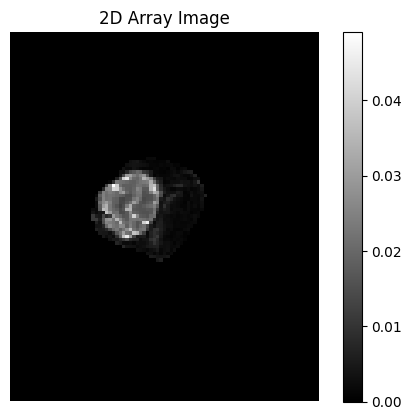

In [86]:
import numpy as np
import matplotlib.pyplot as plt

index = 15

# print(np.unique(outputarray))
# Example 2D array (you can replace this with your own array)
image = outputarray[index,:,:]
print(np.unique(image))

# Plotting the 2D array as an image
plt.imshow(image, cmap='gray')  # Use 'gray' for grayscale or try 'viridis', 'hot', etc.
plt.colorbar()  # Optional: adds a color scale bar
plt.title('2D Array Image')
plt.axis('off')  # Hide axis ticks
plt.show()


In [15]:
for batch_idx, (inputs, Age) in enumerate(train_loader):
    print(inputs.shape)

torch.Size([4, 91, 109, 91])
torch.Size([4, 91, 109, 91])
torch.Size([4, 91, 109, 91])
torch.Size([4, 91, 109, 91])
torch.Size([4, 91, 109, 91])
torch.Size([4, 91, 109, 91])
torch.Size([4, 91, 109, 91])
torch.Size([4, 91, 109, 91])
torch.Size([4, 91, 109, 91])
torch.Size([4, 91, 109, 91])
torch.Size([4, 91, 109, 91])


EOFError: Compressed file ended before the end-of-stream marker was reached